# Laboratorio 1: Regresión en California

En este laboratorio deben hacer experimentos de regresión con el conjunto de datos "California Housing dataset".

Estudiarán el dataset, harán visualizaciones y seleccionarán atributos relevantes a mano.

Luego, entrenarán y evaluarán diferentes tipos de regresiones, buscando las configuraciones que mejores resultados den.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge


## Carga del Conjunto de Datos

Cargamos el conjunto de datos y vemos su contenido.

In [2]:
from sklearn.datasets import fetch_california_housing
X_california, y_california = fetch_california_housing(return_X_y=True, as_frame=True)


* cargamos el dataset de viviendas de California.
* X_california: contiene las columnas como ingreso medio, número de habitaciones, etc.
* y_california: contiene la variable objetivo (dependiente), que en este dataset es MedHouseVal (valor medio de la vivienda en la zona).

In [3]:
california = fetch_california_housing()
california.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

* obtenemos las claves (keys) del objeto que devuelve fetch_california_housing()

In [4]:
print(california['DESCR'])  # descripción del dataset
#california['feature_names'] # nombres de los atributos para cada columna de 'data'
#california['data']           # matriz con los datos de entrada (atributos)
#print(california['target']) # vector de valores a predecir

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

Lo que consideramos mas importante de esta descripción

* Cantidad de muestras: 20,640 registros.
* Cantidad de atributos: 8 variables predictoras + 1 variable objetivo.

Variables:

* MedInc: ingreso medio
* HouseAge: antigüedad promedio
* AveRooms: promedio de habitaciones por hogar
* AveBedrms: promedio de dormitorios por hogar
* Population: población del grupo de bloques
* AveOccup: promedio de ocupantes por hogar
* Latitude, Longitude: coordenadas geográficas

Objetivo (target):

* MedHouseVal: valor medio de la vivienda en cientos de miles de dólares

In [5]:
california['data'].shape, california['target'].shape

((20640, 8), (20640,))

* Verificamos la cantidad de filas (20640) y columnas (8)
* Verificamos los valores objetivos (20640)

## División en Entrenamiento y Evaluación

Dividimos aleatoriamente los datos en 80% para entrenamiento y 20% para evaluación:

In [6]:
from sklearn.model_selection import train_test_split
X, y = california['data'], california['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=0)
X_train.shape, X_test.shape

((16512, 8), (4128, 8))

Comenzamos el entrenamiento y evaluación:

* X: tenemos las features (california['data'])
* y: tenemos el target (california['target'])

Dividimos el dataset para comenzar el entrenamiento:

* X_train, y_train: 80% del total para entrenamiento
* X_test, y_test: 20% para prueba
  * Esto lo hacemos con train_test_split y train_size=0.8.

Siendo el resultado el siguiente
* X_train.shape == (16512, 8): 16.512 filas para entrenamiento, 8 columnas.
* X_test.shape == (4128, 8): 4.128 filas para prueba, 8 columnas.



In [7]:
y.shape

(20640,)

In [8]:
y_test.shape

(4128,)

* y.shape: 20.640 valores, uno por cada muestra del dataset original.
* y_test.shape: 4128 valores, el 20% que se usarán para evaluar el modelo

# Ejercicio 1: Descripción de los Datos y la Tarea

Responda las siguientes preguntas:

1. ¿De qué se trata el conjunto de datos?
2. ¿Cuál es la variable objetivo que hay que predecir? ¿Qué significado tiene?
3. ¿Qué información (atributos) hay disponibles para hacer la predicción?
4. ¿Qué atributos imagina ud. que serán los más determinantes para la predicción?
5. ¿Qué problemas observa a priori en el conjunto de datos? ¿Observa posibles sesgos, riesgos, dilemas éticos, etc? Piense que los datos pueden ser utilizados para hacer predicciones futuras.

**No hace falta escribir código para responder estas preguntas.**

1. El dataset California Housing es un conjunto de datos que se obtuvo a partir del censo de EE.UU. de 1990, utilizando una fila por grupo de bloques censales. Un grupo de bloques es la unidad geográfica más pequeña para la que la Oficina del Censo de EE.UU. publica datos de muestra (un grupo de bloques suele tener una población de 600 a 3.000 personas).

2. La variable objetivo a predecir es el valor medio de la vivienda en los distritos de California (a partir de otras características del bloque), expresado en cientos de miles de dólares (100.000 $).

3. El dataset cuenta con 20.640 registros y 8 variables (mas la variable target a predecir):

    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

  Ademas el dataset no cuenta con valores nulos.

4. A prori, se estima que los atributos que mas informacion aportaran para el objetivo de predecir el precio medio de las viviendas son:
    - MedInc (Ingreso medio): Es probable que esté fuertemente correlacionado con el valor de las viviendas para poder adquirirlas.
    - HouseAge: la antiguedad de la vivienda claramente deberia tener influencia en el precio, ya que las propiedades menos antiguas deberian ser mas caras y viceverza (a menos que este recien remodelada).
    - AveRooms: la cantidad de ambientes tambien debe aportar informacion importante a la hora de predecir el precio, ya que es una caracteristica principal de la vivienda.
    - AveBedrms: idem anterior.
    - Latitude y Longitude: se consideran que son importantes ya que una buena ubicacion puede hacer la diferencia en el precio de la vivienda.

5. Observamos los siguientes puntos:
    - Como cada registro del dataset esta compuesto por un grupo de bloques (un grupo de bloques suele tener una población de 600 a 3.000 personas), claramente esta agrupacion puede afectar la interpretacion de los resultados ya que no se estan tratando propiedades en particular sino conjunto de propiedades. Por lo tanto si dentro de ese conjunto hay viviendas muy caras o muy baratas, el resultado no deja de ser un promedio del grupo de bloques.

    - Desactualización de los datos, es un censo del 1990, por lo que podrían no reflejar las condiciones actuales del mercado inmobiliario

    - Los datos están agregados por bloque, no son datos individuales de viviendas. Esto puede ocultar variaciones dentro de un mismo bloque y generar errores de interpretación

    - Como la variable AveRooms y AveBedrms hace referencia a un promedio de ambientes o dormitorios de cada "hogar" (siendo hogar un grupo de personas que residen en una vivienda), estas columnas pueden tomar valores sorprendentemente grandes para grupos de bloques con pocos hogares y muchas casas vacías, como los complejos vacacionales. En estes casos se puede estar sesgando la informacion.
    

    

# Ejercicio 2: Visualización de los Datos

1. Para cada atributo de entrada, haga una gráfica que muestre su relación con la variable objetivo.
2. Estudie las gráficas, identificando **a ojo** los atributos que a su criterio sean los más informativos para la predicción.
3. Para ud., ¿cuáles son esos atributos? Lístelos en orden de importancia.

## 2.1) Para cada atributo de entrada, haga una gráfica que muestre su relación con la variable objetivo.



## 2.2) Estudie las gráficas, identificando a ojo los atributos que a su criterio sean los más informativos para la predicción.

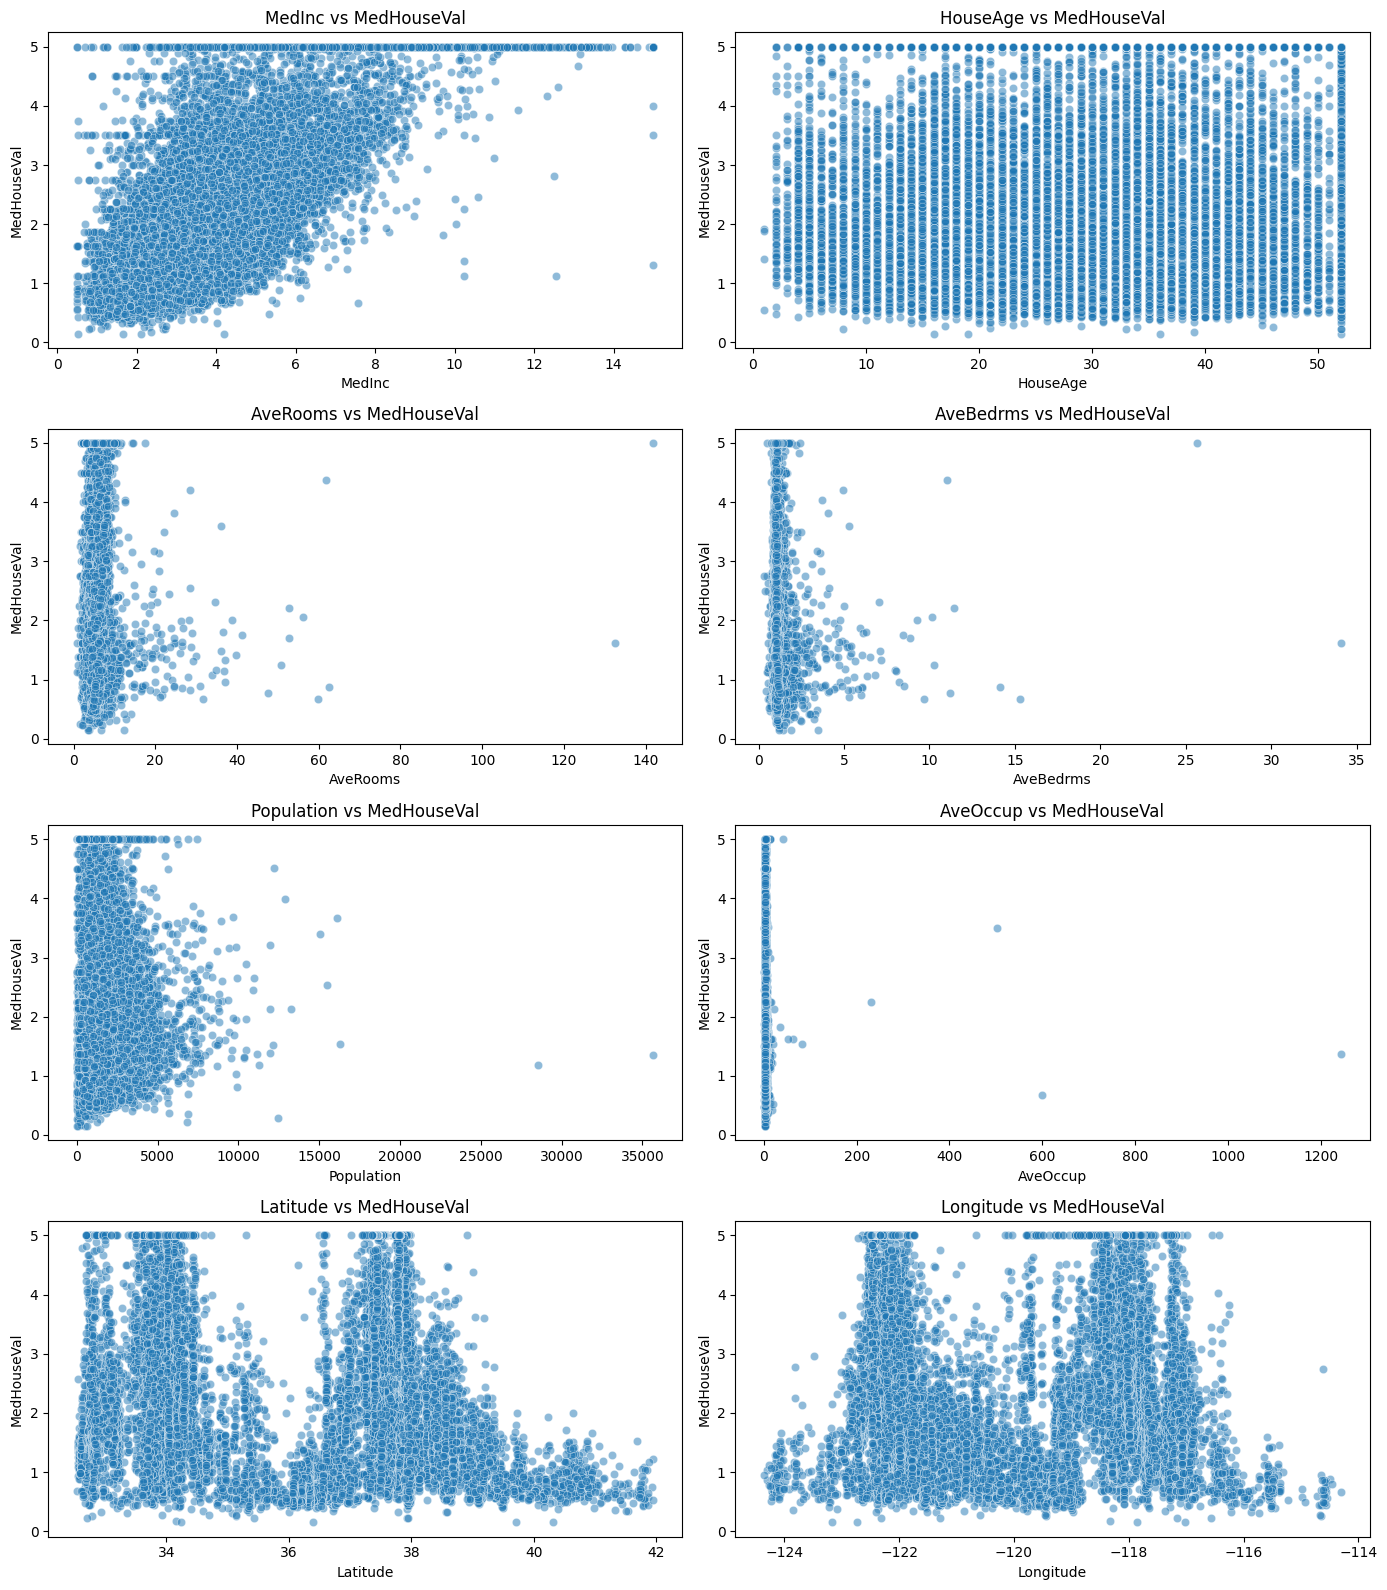

In [9]:
df = pd.DataFrame(california.data, columns=california.feature_names)
df['MedHouseVal'] = california.target

# Creamos una grilla de subplots
fig, axs = plt.subplots(4, 2, figsize=(14, 16))
axs = axs.flatten()

# Iteramos sobre cada feature para graficar su relación con MedHouseVal
for i, column in enumerate(df.columns[:-1]):  # Excluye MedHouseVal
    sns.scatterplot(data=df, x=column, y='MedHouseVal', ax=axs[i], alpha=0.5)
    axs[i].set_title(f'{column} vs MedHouseVal')

plt.tight_layout()
plt.show()

Podemos inferir por lo visualizado, con el atributo relacionado al valor medio de la vivienda:

* **MedInc:** Fuerte relación positiva: más ingreso → más valor
* **HouseAge:** Relación leve o no lineal
* **AveRooms:** Relación positiva, aunque puede tener outliers
* **AveBedrms:** Relación más débil que AveRooms
* **Population:** Muy dispersa, poca correlación clara
* **AveOccup:** Patrón extraño, con valores extremos
* **Latitude:**	Patrón claro con zonas costeras (norte/sur)
* **Longitude:** También muestra influencia geográfica

_**MedInc**_ vs. _**Target**_

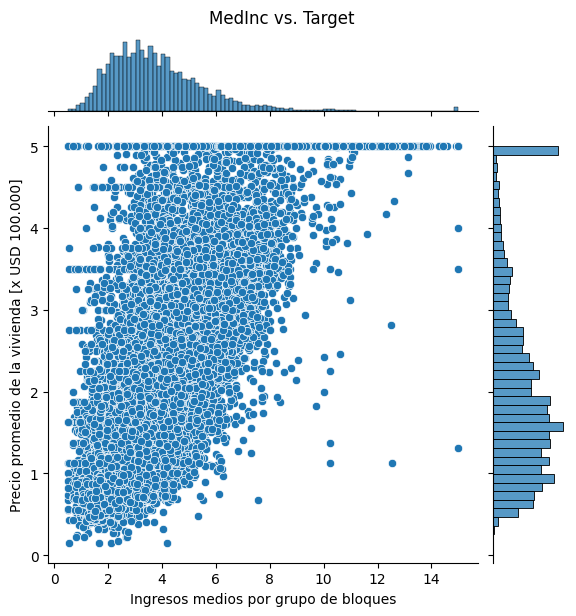

In [12]:
# Crear un DataFrame para facilitar el uso de seaborn
df = pd.DataFrame(X, columns=california['feature_names'])
df['target'] = y

# Crear el scatter plot con histogramas para MedInc
feature = 'MedInc'
sns.jointplot(x=feature, y="target", data=df, kind="scatter")
plt.suptitle(f'{feature} vs. Target', y=1.02)
plt.xlabel('Ingresos medios por grupo de bloques')
plt.ylabel('Precio promedio de la vivienda [x USD 100.000]')
plt.show()

* Se puede apreciar un cierto grado de correlacion positivo, es decir, que a medida que aumenta el ingreso medio aumenta el precio promedio de la vivienda, hablando siempre del grupo de bloques.
* Se puede apreciar una cantidad importante de viviendas a un precio elevado (proxmo a los USD 500.000) para todo el rango de ingresos medios.

**Dada la buena correlacion se considera un buen atributo para predecir el objetivo**


_**HouseAge**_ vs. _**Target**_

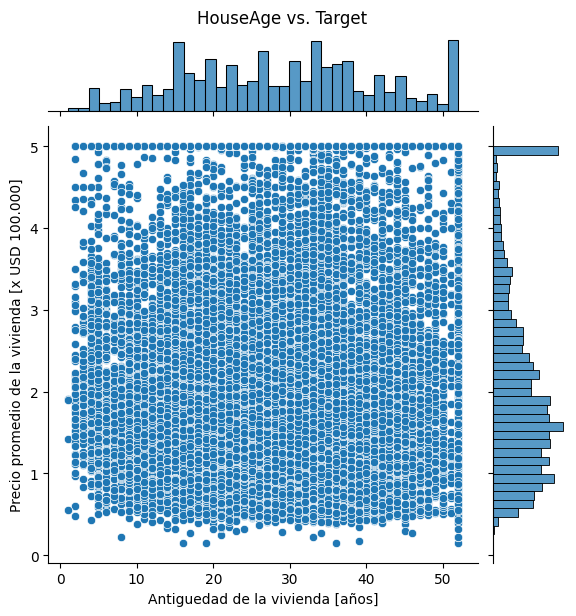

In [13]:
# Crear el scatter plot con histogramas para HouseAge
feature = 'HouseAge'
sns.jointplot(x=feature, y="target", data=df, kind="scatter")
plt.suptitle(f'{feature} vs. Target', y=1.02)
plt.xlabel('Antiguedad de la vivienda [años]')
plt.ylabel('Precio promedio de la vivienda [x USD 100.000]')
plt.show()

* Se observa que no hay una correlacion determianda, ni positiva ni negativa.
* Al igual que en el caso anterior se observa una importante cantidad de viviendas de elevado costo para todos los valores de 'HouseAge'
* Tambien se observa una gran cantidad de vivendas para una edad mayor a los 50 años, para todos los precios.

**No se considera que la edad es una buena variable para predecir el objetivo, ya que no aporta suficiente informacion**

_**AveRooms**_ vs. _**Target**_

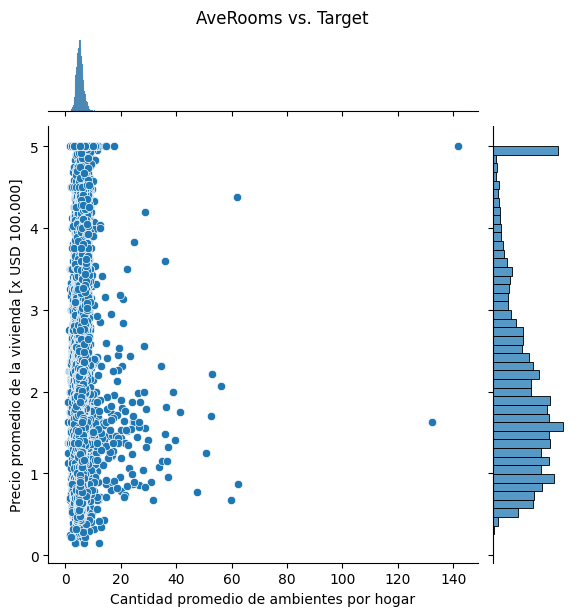

In [14]:
# Crear el scatter plot con histogramas para AveRooms
feature = 'AveRooms'
sns.jointplot(x=feature, y="target", data=df, kind="scatter")
plt.suptitle(f'{feature} vs. Target', y=1.02)
plt.xlabel('Cantidad promedio de ambientes por hogar')
plt.ylabel('Precio promedio de la vivienda [x USD 100.000]')
plt.show()

* Como en algunos grupos de bloques hay muchas casas vacacionales que no se consideran hogar, el numero de habitaciones promedios es elevado siendo datos que confunden o sesgan la informacion.
* Al igual que en los casos anteriores se observan viviendas con valores elevados para valores de AveRooms entre 0 y 20.

**Dado la importancia de esta variable, creo que seria necesario eleminar los valores extremos para poder tenerla en cuenta a la hora de predecir el objetivo**

_**AveBedrms**_ vs. _**Target**_

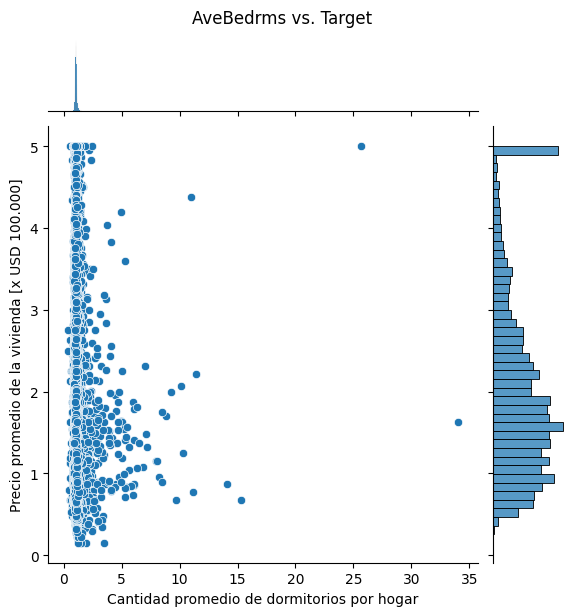

In [15]:
# Crear el scatter plot con histogramas para AveBedrms
feature = 'AveBedrms'
sns.jointplot(x=feature, y="target", data=df, kind="scatter")
plt.suptitle(f'{feature} vs. Target', y=1.02)
plt.xlabel('Cantidad promedio de dormitorios por hogar')
plt.ylabel('Precio promedio de la vivienda [x USD 100.000]')
plt.show()

* Los comentarios anteriores son totalmente aplicables a esta variable.


_**Population**_ vs. _**Target**_

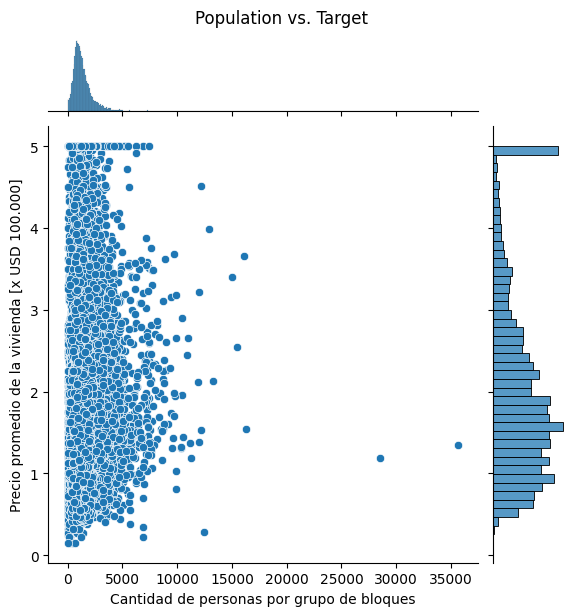

In [16]:
# Crear el scatter plot con histogramas para Population
feature = 'Population'
sns.jointplot(x=feature, y="target", data=df, kind="scatter")
plt.suptitle(f'{feature} vs. Target', y=1.02)
plt.xlabel('Cantidad de personas por grupo de bloques')
plt.ylabel('Precio promedio de la vivienda [x USD 100.000]')
plt.show()

* Se observan valores extremos a la derecha
* La mayoria de los grupo de bloques estan compuestos entre 0 y 5000 personas
* No existe una correlacion muy importante con la variable precio
* Se observa que las viviendas mas caras se da cuando el numero de personas por grupo de bloques es menor.

**Se considera que no aporta suficiente informacion para predecir el objetivo, quiza elimnando valores extremos se pueda apreciar una cierta correlacion negativa**

_**AveOccup**_ vs. _**Target**_

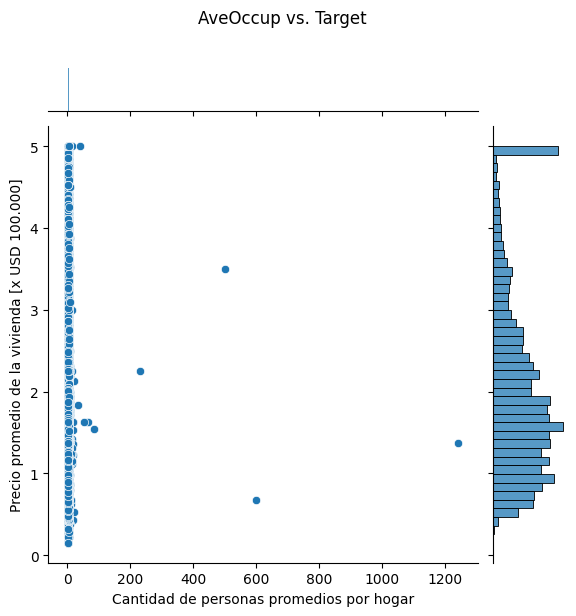

In [17]:
# Crear el scatter plot con histogramas para AveOccup
feature = 'AveOccup'
sns.jointplot(x=feature, y="target", data=df, kind="scatter")
plt.suptitle(f'{feature} vs. Target', y=1.02)
plt.xlabel('Cantidad de personas promedios por hogar')
plt.ylabel('Precio promedio de la vivienda [x USD 100.000]')
plt.show()

* Se observan valores extremos que no son coherentes como cantidad de personas promedios por hogar. Valores entre 200 y 1200 seguramente estan afectados debido a la forma de registrar los datos por grupo de bloques.

**Para poder considerar esta variable sera necesario eliminar los datos extremos**

_**Latitude**_ vs. _**Target**_

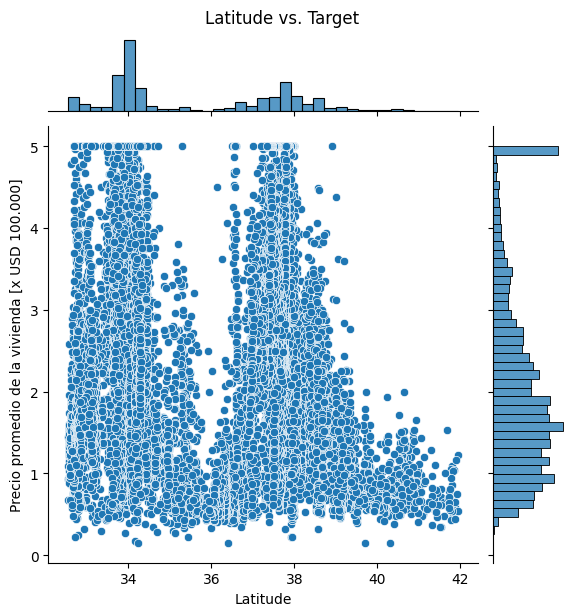

In [18]:
# Crear el scatter plot con histogramas para Latitude
feature = 'Latitude'
sns.jointplot(x=feature, y="target", data=df, kind="scatter")
plt.suptitle(f'{feature} vs. Target', y=1.02)
plt.xlabel('Latitude')
plt.ylabel('Precio promedio de la vivienda [x USD 100.000]')
plt.show()

_**Longitude**_ vs. _**Target**_

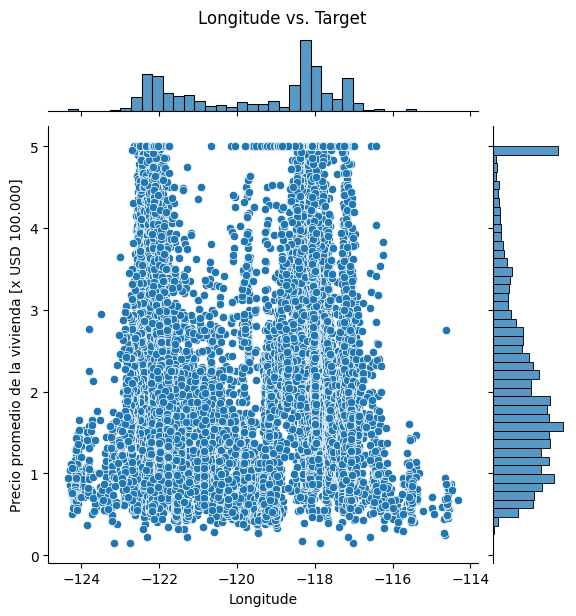

In [19]:
# Crear el scatter plot con histogramas para Longitude
feature = 'Longitude'
sns.jointplot(x=feature, y="target", data=df, kind="scatter")
plt.suptitle(f'{feature} vs. Target', y=1.02)
plt.xlabel('Longitude')
plt.ylabel('Precio promedio de la vivienda [x USD 100.000]')
plt.show()

Observaciones para Latitud y Longitud
* Si bien no se observan correlaciones importantes, si se puede apreciar ciertas franjas de longitud y latitud donde hay grandes cantidfades de hogares para diferentes valores de precios.
* Ademas se pueden apreciar sectores (latitud entre 40 y 42 y longitud entre -116 y -114) donde solo hay viviendas valores bajos.



## 2.3) Para ud., ¿cuáles son esos atributos? Lístelos en orden de importancia.

Para complementar la informacion de los puntos anteriores y poder responder la pregunta, se crea la matriz de correlacion para la variable objetivo.

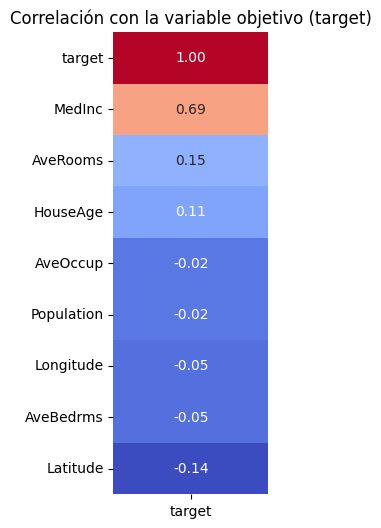

In [20]:
# Calcula la matriz de correlación
correlation_matrix = df.corr()

# Extrae la columna de correlación con la variable objetivo 'target'
target_correlation = correlation_matrix[['target']].sort_values(by='target', ascending=False)

# Dibuja el heatmap solo para la columna 'target'
plt.figure(figsize=(2, 6)) # Ajusta el tamaño para una sola columna
sns.heatmap(target_correlation, annot=True, cmap='coolwarm', fmt=".2f", cbar=False)
plt.title('Correlación con la variable objetivo (target)')
plt.show()

De acuerdo a lo mencionado en los puntos 1 y 2, como asi tambien en funcion de la matriz de correlacion, se determina el siguiente listado de variables en funcion de su importancia para predecir la variable objetivo:
1. **MedInc:** Mayor ingreso, mayor valor de la vivienda.
2. **AveRooms** (se requiere eliminar datos extremos): mas habitaciones suele indicar mayor valor.
3. **AveBedrms** (se requiere eliminar datos extremos): muy relacionada a AveRooms, pero aporta menos
4. **Longitude** y 'Latitude': juntas identifican la ubicación geográfica



# Ejercicio 3: Regresión Lineal

1. Seleccione **un solo atributo** que considere puede ser el más apropiado.
2. Instancie una regresión lineal de **scikit-learn**, y entrénela usando sólo el atributo seleccionado.
3. Evalúe, calculando error cuadrático medio para los conjuntos de entrenamiento y evaluación.
4. Grafique el modelo resultante, junto con los puntos de entrenamiento y evaluación.
5. Interprete el resultado, haciendo algún comentario sobre las cualidades del modelo obtenido.

**Observación:** Con algunos atributos se puede obtener un error en test menor a 50.

## 3.1) Seleccione un solo atributo que considere puede ser el más apropiado.

In [21]:
featureLinearRegression= 'MedInc'

* Seleccionamos el atributo MedInc, dada su buena correlación con la variable objetivo

## 3.2) Instancie una regresión lineal de scikit-learn, y entrénela usando sólo el atributo seleccionado.

Se instancia el modelo de regresion lineal.
* [Documentacion](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)

Luego seleccionamos los datos de entrenamiento y testeo para el modelo
* X_train_LR
* X_test_LR

Seleccionamos los datos a predecir para el entrenamiento y testeo:
* y_train_LR
* y_test_LR

Finalmente se entrena el modelo con el metodo _**.fit()**_


In [22]:
# Instanciacion del modelo
model= LinearRegression()

# Seleccion de los datos de entrenamiento y testeo
selector = (np.array(california['feature_names']) ==  featureLinearRegression)

X_train_LR = X_train[:, selector]
X_test_LR = X_test[:, selector]


y_train_LR = y_train
y_test_LR = y_test

# Entrenamiento del modelo
model.fit(X_train_LR, y_train_LR)


LinearRegression()

## 3.3) Evalúe, calculando error cuadrático medio para los conjuntos de entrenamiento y evaluación.

Se hace la prediccion y se evalua

In [23]:
y_train_pred_LR = model.predict(X_train_LR)
y_val_pred_LR = model.predict(X_test_LR)

# Calculo del error cuadratico medio
train_error_LR = mean_squared_error(y_train_LR, y_train_pred_LR)
val_error_LR = mean_squared_error(y_test_LR, y_val_pred_LR)
print(f'Train error: {train_error_LR:0.2}')
print(f'Test error: {val_error_LR:0.2}')

Train error: 0.7
Test error: 0.72


* Calculamos el error cuadrático medio sobre los datos de entrenamiento y validación/test, siendo los valores:
  * Train error: 0.7
  * Test error: 0.72
* Un MSE de 0.72 significa que: El modelo, en promedio, se equivoca en 85.000 dólares al predecir el valor de una vivienda.



## 3.4) Grafique el modelo resultante, junto con los puntos de entrenamiento y evaluación.

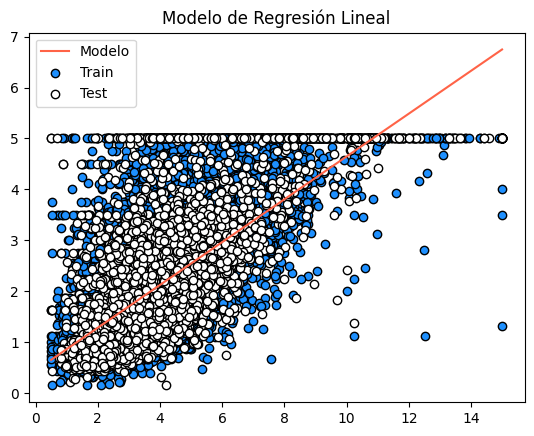

In [24]:
x_start = min(np.min(X_train_LR), np.min(X_test_LR))
x_end = max(np.max(X_train_LR), np.max(X_test_LR))
x = np.linspace(x_start, x_end, 200).reshape(-1, 1)
plt.plot(x, model.predict(x), color="tomato", label="Modelo")

plt.scatter(X_train_LR, y_train_LR, facecolor="dodgerblue", edgecolor="k", label="Train")
plt.scatter(X_test_LR, y_test_LR, facecolor="white", edgecolor="k", label="Test")
plt.title("Modelo de Regresión Lineal")
plt.legend()
plt.show()

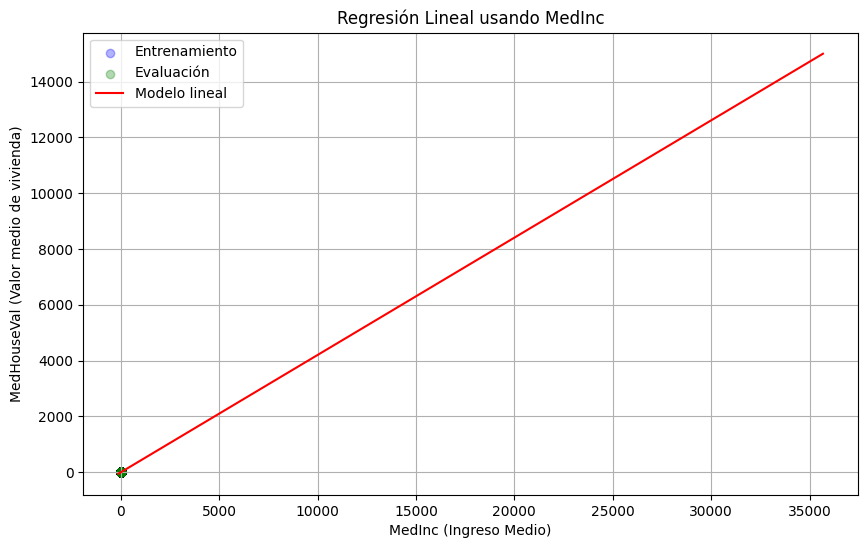

In [25]:
# Graficar puntos de entrenamiento y línea de regresión
plt.figure(figsize=(10, 6))

# Puntos reales de entrenamiento
plt.scatter(X_train_LR, y_train_LR, color='blue', alpha=0.3, label="Entrenamiento")

# Puntos reales de test
plt.scatter(X_test_LR, y_test_LR, color='green', alpha=0.3, label="Evaluación")

# Línea del modelo (regresión lineal)
x_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_line = model.predict(x_line)
plt.plot(x_line, y_line, color='red', label='Modelo lineal')

plt.xlabel("MedInc (Ingreso Medio)")
plt.ylabel("MedHouseVal (Valor medio de vivienda)")
plt.title("Regresión Lineal usando MedInc")
plt.legend()
plt.grid(True)
plt.show()

* El modelo encuentra una relación lineal clara y creciente entre el ingreso medio (MedInc) y el valor medio de la vivienda (MedHouseVal).

## 3.5) Interprete el resultado, haciendo algún comentario sobre las cualidades del modelo obtenido.

El modelo de Regreson Lineal debe tener la siguiente forma:


$$f_{w^*}((1, x)) = w_0 + x_1 w_1^*$$


Por lo tanto calculamos los coeficiente w0 y w1 para armar nuestro modelo.




In [26]:
# Coeficiente w1
model.coef_

array([0.42032178])

In [27]:
# Coeficinete w0
model.intercept_

np.float64(0.4432063522765708)

El modelo queda de la siguiente manera:

$$y=0.44 + 0.42 * x $$

A continuacion se vuelve a graficar para mostrar que es el mismo del grafico anterior.


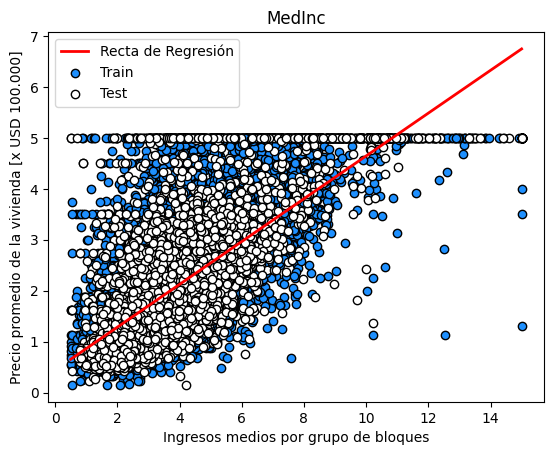

In [28]:
# Crear un rango de valores para el eje x
x_range = np.array([X_train_LR.min(), X_train_LR.max()])

# Calcular los valores correspondientes en el eje y utilizando la pendiente y el intercepto
y_range = model.coef_[0] * x_range + model.intercept_

# Dibujar la recta
plt.plot(x_range, y_range, color='red', linewidth=2, label='Recta de Regresión')
plt.scatter(X_train_LR, y_train_LR, facecolor="dodgerblue", edgecolor="k", label="Train")
plt.scatter(X_test_LR, y_test_LR, facecolor="white", edgecolor="k", label="Test")
plt.title(featureLinearRegression)
plt.xlabel('Ingresos medios por grupo de bloques')
plt.ylabel('Precio promedio de la vivienda [x USD 100.000]')
plt.legend()
plt.show()

Observaciones:
* Se aprecia que la pendiente del modelo copia en cierta medida, la correlacion entre ambos datos.
* El error obtenido tanto en el entrenamiento (0.7) como en el testo (0.72) es bastante elevado, con lo cual seria necesario estudiar si es necesario mejorar el modelo aumentado el grado del polinomio o buscar otra alternativa.
* Se puede mencionar que el modelo no tiene sobreajuste y puede generalizar bien cualquier dato fuera del set de entrenamiento, aunque con bastante error.  


# Ejercicio 4: Regresión Polinomial

En este ejercicio deben entrenar regresiones polinomiales de diferente complejidad, siempre usando **scikit-learn**.

Deben usar **el mismo atributo** seleccionado para el ejercicio anterior.

1. Para varios grados de polinomio, haga lo siguiente:
    1. Instancie y entrene una regresión polinomial.
    2. Prediga y calcule error en entrenamiento y evaluación. Imprima los valores.
    3. Guarde los errores en una lista.
2. Grafique las curvas de error en términos del grado del polinomio.
3. Interprete la curva, identificando el punto en que comienza a haber sobreajuste, si lo hay.
4. Seleccione el modelo que mejor funcione, y grafique el modelo conjuntamente con los puntos.
5. Interprete el resultado, haciendo algún comentario sobre las cualidades del modelo obtenido.

**Observación:** Con algunos atributos se pueden obtener errores en test menores a 40 e incluso a 35.

## 4.1) Para varios grados de polinomio, haga lo siguiente:
1. Instancie y entrene una regresión polinomial.
2. Prediga y calcule error en entrenamiento y evaluación. Imprima los valores.
3. Guarde los errores en una lista.

Antes de comenzar se define los datos de entrenamiento y testeo para el modelo de Regresion Polinomial

* X_train_PR
* X_test_PR


* y_train_PR
* y_test_PR

In [29]:
featurePolinomialRegression= 'MedInc'

# Seleccion de los datos de entrenamiento y testeo
selector = (np.array(california['feature_names']) ==  featurePolinomialRegression)

X_train_PR = X_train[:, selector]
X_test_PR = X_test[:, selector]

y_train_PR = y_train
y_test_PR = y_test

Resolvemos para polinomios desde grado "0" hasta "10"

In [30]:
train_errors = []
val_errors = []
grados = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
for grado in grados:
    # train:
    pf = PolynomialFeatures(grado)
    lr = LinearRegression(fit_intercept=False)
    model = make_pipeline(pf, lr)
    model.fit(X_train_PR, y_train_PR)

    # predict:
    y_train_pred_PR = model.predict(X_train_PR)
    y_val_pred_PR = model.predict(X_test_PR)

    # evaluate:
    train_error = mean_squared_error(y_train_PR, y_train_pred_PR)
    val_error = mean_squared_error(y_test_PR, y_val_pred_PR)
    train_errors.append(train_error)
    val_errors.append(val_error)

¿Qué hacemos?

* Definimos una lista de grados de polinomio (0 a 10).
* Para cada grado:
  * Creamos un modelo de regresión polinómica usando PolynomialFeatures(grado) y LinearRegression.
  * Entrenamos el modelo sobre X_train_PR (usando solo 'MedInc').
  * Predecimos sobre entrenamiento y test.
  * Calculamos el error cuadrático medio para ambos conjuntos.



## 4.2) Grafique las curvas de error en términos del grado del polinomio.


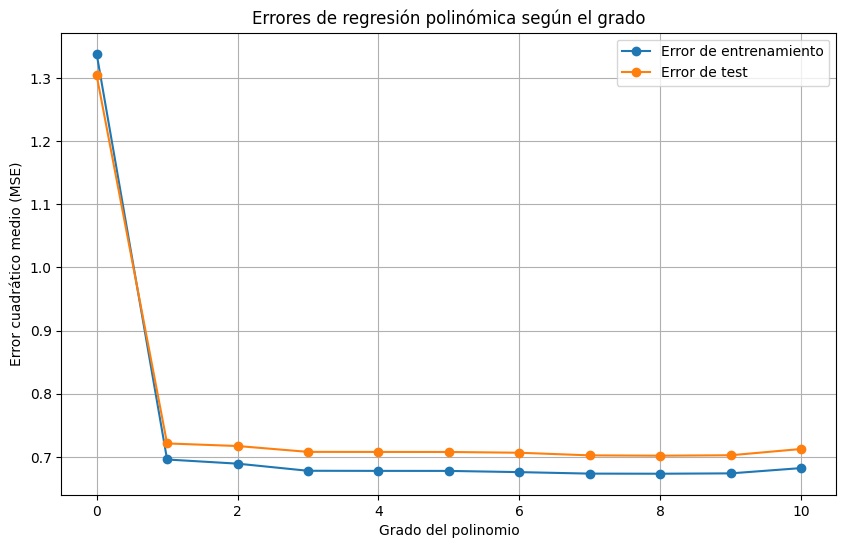

In [31]:
plt.figure(figsize=(10, 6))
plt.plot(grados, train_errors, label='Error de entrenamiento', marker='o')
plt.plot(grados, val_errors, label='Error de test', marker='o')
plt.xlabel('Grado del polinomio')
plt.ylabel('Error cuadrático medio (MSE)')
plt.title('Errores de regresión polinómica según el grado')
plt.legend()
plt.grid(True)
plt.show()

## 4.3) Interprete la curva, identificando el punto en que comienza a haber sobreajuste, si lo hay.


* Se puede mencionar que el modelo es estable y a medida que aumentamos el grado del polinomio el mismo mantiene el error de entrenamiento y testeo muy similares.

* Se puede decir que en ninguno de los grados calculados, se observa que el modelo comienza a sobreajustar.

* Finalmente podemos decir que los errores minimos se dan para el grado 9, pero en una solucion de compromiso entre el error y el calculo computacional, podemos decir que el modelo de grado 3 es el adecuado.

## 4.4) Seleccione el modelo que mejor funcione, y grafique el modelo conjuntamente con los puntos.


Teniendo en cuenta el modelo de la siguiente manera:

$$f_{w^*}(x) = x^\top w^* = \sum_{k=1}^K x_k w^*_k$$

Con $K=3$ y contemplando el termino independiente, tenemos:

$$f_{w^*}(x) = w_0 + x_1 w_1^* + x_2^2  w_2^*+ x_3^3  w_3^*$$



Calculamos los coeficientes $$w_0, w_1, w_2, w_3$$

In [32]:
grado = 3
model = make_pipeline(PolynomialFeatures(grado), LinearRegression())
model.fit(X_train_PR, y_train_PR);
print('Coeficientes w1, w2 y w3')
print(model.named_steps["linearregression"].coef_) # Coeficientes w1, w2 y w3
print('Coeficiente w0')
model.named_steps["linearregression"].intercept_# Coeficientes w0

Coeficientes w1, w2 y w3
[ 0.          0.14466063  0.06197842 -0.00362023]
Coeficiente w0


np.float64(0.7601848230871917)

El modelo queda de la siguiente manera:

$$y = 0.76 + 0.14 x + 0.062 x^2 -0.0036 x^3$$

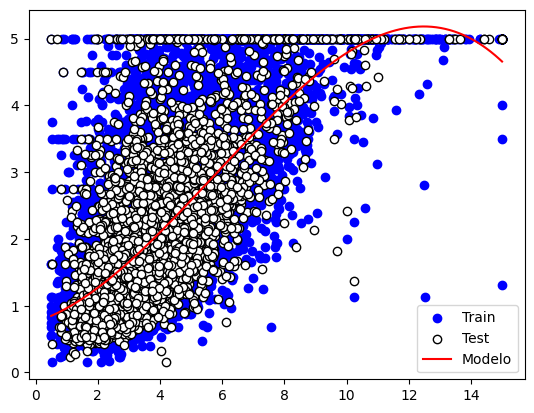

In [34]:
plt.scatter(X_train_PR, y_train_PR, color="blue", label="Train")
plt.scatter(X_test_PR, y_test_PR, color="white", edgecolor="k", label="Test")
plt.plot(x, model.predict(x.reshape(-1, 1)), color="red", label="Modelo")
#plt.plot(x, f_x, color="green", label="$\sin(2\pi x)$")
plt.legend()
plt.show()

Se calcula el error para el modelo de grado 3

In [35]:
# predict:
y_train_pred_PR = model.predict(X_train_PR)
y_val_pred_PR = model.predict(X_test_PR)

# evaluate:
train_error_PR = mean_squared_error(y_train_PR, y_train_pred_PR)
val_error_PR = mean_squared_error(y_test_PR, y_val_pred_PR)

print(f'Train error: {train_error_PR:0.2}')
print(f'Test error: {val_error_PR:0.2}')

Train error: 0.68
Test error: 0.71


## 4.5) Interprete el resultado, haciendo algún comentario sobre las cualidades del modelo obtenido.

Observaciones:
* A diferencia del modelo lineal se puede apreciar que ajusta un poco mejor para los valores superiores.
* Sera necesario analizar si el costo computacional de un modelo poliniomial de grado 3 se justifica ante una regresion lineal, ya que los errores no son muy distintos.

## Ejercicio 5: Regresión con más de un Atributo

En este ejercicio deben entrenar regresiones que toman más de un atributo de entrada.

1. Seleccione **dos o tres atributos** entre los más relevantes encontrados en el ejercicio 2.
2. Repita el ejercicio anterior, pero usando los atributos seleccionados. No hace falta graficar el modelo final.
3. Interprete el resultado y compare con los ejercicios anteriores. ¿Se obtuvieron mejores modelos? ¿Porqué?

En funcion del Ejercicio 2, los atributos que se seleccionan son:
* 'MedInc'
* 'AveRooms'
* 'AveBedrms'


In [37]:
selector = (np.array(california['feature_names']) == 'MedInc') | (np.array(california['feature_names']) == 'AveRooms') | (np.array(california['feature_names']) == 'AveBedrms')

## 5.2) Repita el ejercicio anterior, pero usando los atributos seleccionados. No hace falta graficar el modelo final.

Antes de comenzar se define los datos de entrenamiento y testeo para el modelo de Regresion Polinomial con 3 atributos (feature):

* X_train_PR_3f
* X_test_PR_3f


* y_train_PR_3f
* y_test_PR_3f

In [38]:
X_train_PR_3f = X_train[:, selector]
X_test_PR_3f = X_test[:, selector]

y_train_PR_3f = y_train
y_test_PR_3f = y_test

Resolvemos para polinomios desde grado "0" hasta "6"

In [39]:
train_errors = []
val_errors = []
grados = [0, 1, 2, 3, 4, 5, 6]
for grado in grados:
    # train:
    pf = PolynomialFeatures(grado)
    lr = LinearRegression(fit_intercept=False)
    model = make_pipeline(pf, lr)
    model.fit(X_train_PR_3f, y_train_PR_3f)

    # predict:
    y_train_pred_PR_3f = model.predict(X_train_PR_3f)
    y_val_pred_PR_3f = model.predict(X_test_PR_3f)

    # evaluate:
    train_error = mean_squared_error(y_train_PR_3f, y_train_pred_PR_3f)
    val_error = mean_squared_error(y_test_PR_3f, y_val_pred_PR_3f)
    train_errors.append(train_error)
    val_errors.append(val_error)

Se grafica las curvas de error de entrenamiento y testeo en funcion del grado del polinomio.

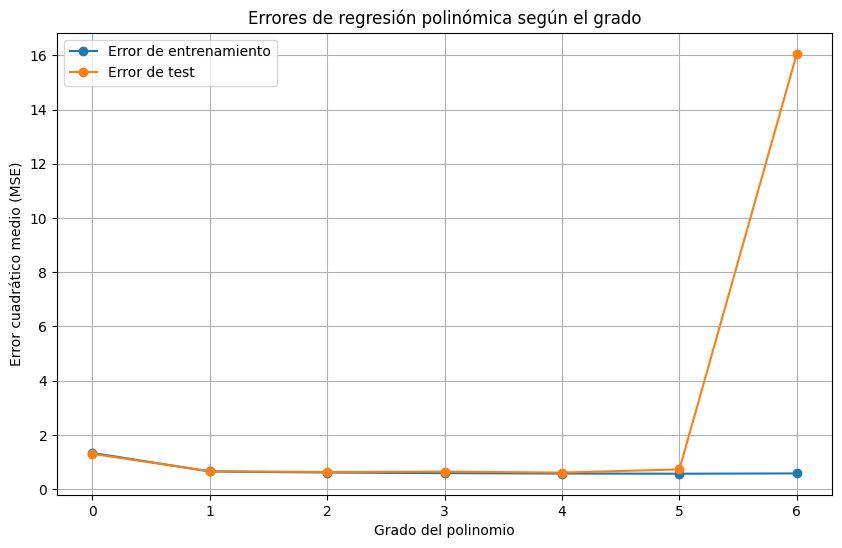

In [40]:
plt.figure(figsize=(10, 6))
plt.plot(grados, train_errors, label='Error de entrenamiento', marker='o')
plt.plot(grados, val_errors, label='Error de test', marker='o')
plt.xlabel('Grado del polinomio')
plt.ylabel('Error cuadrático medio (MSE)')
plt.title('Errores de regresión polinómica según el grado')
plt.legend()
plt.grid(True)
plt.show()

## 5.3) Interprete el resultado y compare con los ejercicios anteriores. ¿Se obtuvieron mejores modelos? ¿Porqué?

* No se obtuvieron mejores resultados ya que el error sigue siendo muy similar a tomar un solo atributo.
* Para grado superior a 5 el modelo comienza a sobreajustar y el error de testeto se hace muy grande en comparacion con el de entrenamiento.
* Quiza no se obtiene mejores resultados por 2 motivos:
  * Los atributos seleccionados no son los mas adecuados
  * Los 2 atributos que se incorporaron (AveRooms y AveBedrms) no aportan suficiente informacion adicional. Ademas de que estas variables tienen un poco de sesgo debido a la forma de recolectar los datos en el censo.
  

# Más ejercicios (opcionales)

# Ejercicio 6: A Todo Feature

Entrene y evalúe regresiones pero utilizando todos los atributos de entrada (va a andar mucho más lento). Estudie los resultados.

Se consideran todos los atributos del dataset

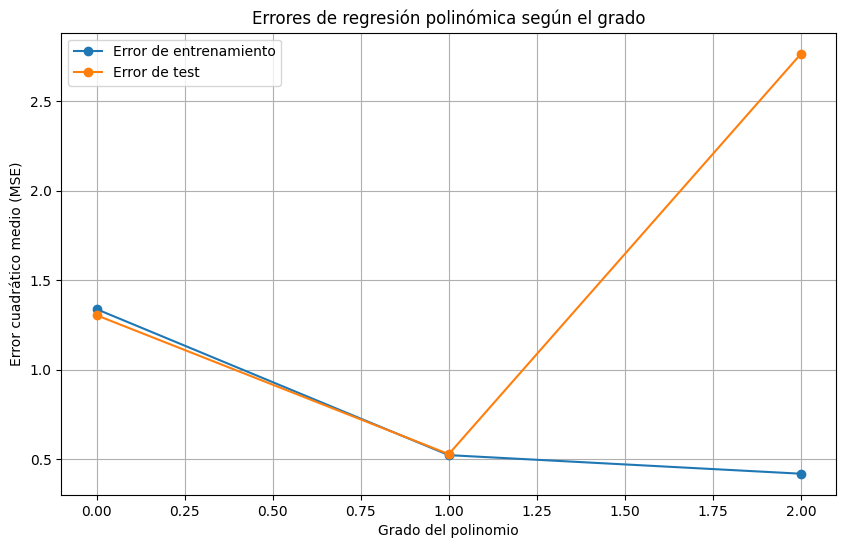

In [41]:
# 1. Atributos
california['feature_names']
# ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

# 2. Seleccionamos todos los atributos
selector = (np.array(california['feature_names']) == 'MedInc')         \
            | (np.array(california['feature_names']) == 'HouseAge')    \
            | (np.array(california['feature_names']) == 'AveRooms')    \
            | (np.array(california['feature_names']) == 'AveBedrms')   \
            | (np.array(california['feature_names']) == 'Population')  \
            | (np.array(california['feature_names']) == 'AveOccup')    \
            | (np.array(california['feature_names']) == 'Latitude')    \
            | (np.array(california['feature_names']) == 'Longitude')

# 3. Definimos el set de datos para entrenamiento y testeto
X_train_PR_AllF = X_train[:, selector]
X_test_PR_AllF = X_test[:, selector]

y_train_PR_AllF = y_train
y_test_PR_AllF = y_test

# 4. Entrenamos el modelo para diferentes grados del polinomio
train_errors = []
val_errors = []
grados = [0, 1, 2]
for grado in grados:
    # train:
    pf = PolynomialFeatures(grado)
    lr = LinearRegression(fit_intercept=False)
    model = make_pipeline(pf, lr)
    model.fit(X_train_PR_AllF, y_train_PR_AllF)

    # predict:
    y_train_pred_PR_AllF = model.predict(X_train_PR_AllF)
    y_val_pred_PR_AllF = model.predict(X_test_PR_AllF)

    # evaluate:
    train_error = mean_squared_error(y_train_PR_AllF, y_train_pred_PR_AllF)
    val_error = mean_squared_error(y_test_PR_AllF, y_val_pred_PR_AllF)
    train_errors.append(train_error)
    val_errors.append(val_error)


# 5. Graficamos los errores en funcion del grado del polinomio
plt.figure(figsize=(10, 6))
plt.plot(grados, train_errors, label='Error de entrenamiento', marker='o')
plt.plot(grados, val_errors, label='Error de test', marker='o')
plt.xlabel('Grado del polinomio')
plt.ylabel('Error cuadrático medio (MSE)')
plt.title('Errores de regresión polinómica según el grado')
plt.legend()
plt.grid(True)
plt.show()




* A partir del grado 1 el error de test es demasiado grande con lo cual se sobreajusta a los datos de entrenamiento.
* Para el polinomio de grado 1: si bien se observa que el error es menor a los modelos de regresion lineal y polinomial de grado 3, se determina que por aspectos relacionados al calculo computacional y simplicidad del modelo; no se justifica tomar todos los atributos del dataset.

# Ejercicio 7: Regularización

Entrene y evalúe regresiones con regularización "ridge". Deberá probar distintos valores de "alpha" (fuerza de la regularización). ¿Mejoran los resultados?

Se realiza la primera prueba para
* Prueba 1: Regresion Lineal con regularizacion Ridge con un solo atributo 'MedInc'

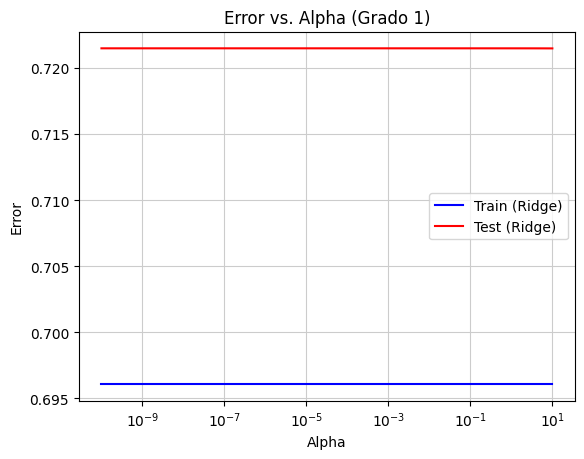

In [42]:
# Prueba 1: Regresion Polinomial de grado 1 con un solo atributo 'MedInc' y regularizacion Ridge
train_errors_P1 = []
val_errors_P1 = []
alphas_ridge = np.logspace(-10, 1, 100) # Use a range of alpha values

# Seleccion del atributo y datos de entrenamiento y testeo
feature = 'MedInc'
selector = (np.array(california['feature_names']) == feature)

X_train_P1 = X_train[:, selector]
X_test_P1 = X_test[:, selector]

y_train_P1 = y_train
y_test_P1 = y_test

for alpha in alphas_ridge:
    # Entrenamiento:
    # Se instancia el modelo de regresion lineal o polinomial grado 1
    pf = PolynomialFeatures(degree=1)
    # Se instancia el modelo de Ridge para los diferentes valores de alpha
    ridge = Ridge(alpha=alpha)
    # Se unifican los modelos
    model_ridge = make_pipeline(pf, ridge)
    model_ridge.fit(X_train_P1, y_train_P1)

    # Prediccion:
    y_train_pred_P1 = model_ridge.predict(X_train_P1)
    y_val_pred_P1 = model_ridge.predict(X_test_P1)

    # evaluate:
    train_error = mean_squared_error(y_train_P1, y_train_pred_P1)
    val_error_ridge_val = mean_squared_error(y_test_P1, y_val_pred_P1)
    train_errors_P1.append(train_error)
    val_errors_P1.append(val_error_ridge_val)

# Graficar las curvas de error en términos del valor de alpha
plt.plot(alphas_ridge, train_errors_P1, color="blue", label="Train (Ridge)")
plt.plot(alphas_ridge, val_errors_P1, color="red", label="Test (Ridge)")
plt.xscale('log')
plt.legend()
plt.xlabel("Alpha")
plt.ylabel("Error")
plt.title("Error vs. Alpha (Grado 1)")
plt.grid(True, which="both", ls="-", color='0.8')
plt.show()




* Prueba 2: Regresion Polinomial de grado 3 con regularizacion Ridge con un solo atributo 'MedInc'

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=8.26753e-20): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=1.06779e-19): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=1.37911e-19): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=1.78119e-19): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarnin

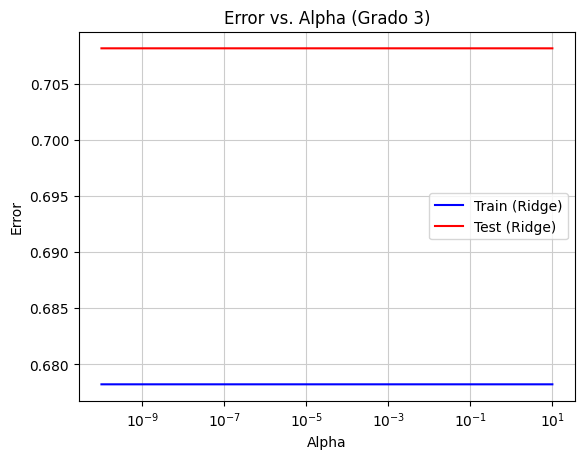

In [43]:
# Prueba 2: Regresion Polinomial de grado 3 con un solo atributo 'MedInc' y regularizacion Ridge
train_errors_P2 = []
val_errors_P2 = []
alphas_ridge = np.logspace(-10, 1, 100) # Use a range of alpha values

# Seleccion del atributo y datos de entrenamiento y testeo
feature = 'MedInc'
selector = (np.array(california['feature_names']) == feature)

X_train_P2 = X_train[:, selector]
X_test_P2 = X_test[:, selector]

y_train_P2 = y_train
y_test_P2 = y_test

for alpha in alphas_ridge:
    # Entrenamiento:
    # Se instancia el modelo de regresion lineal o polinomial grado 1
    pf = PolynomialFeatures(degree=3)
    # Se instancia el modelo de Ridge para los diferentes valores de alpha
    ridge = Ridge(alpha=alpha)
    # Se unifican los modelos
    model_ridge = make_pipeline(pf, ridge)
    model_ridge.fit(X_train_P2, y_train_P2)

    # Prediccion:
    y_train_pred_P2 = model_ridge.predict(X_train_P2)
    y_val_pred_P2 = model_ridge.predict(X_test_P2)

    # evaluate:
    train_error = mean_squared_error(y_train_P2, y_train_pred_P2)
    val_error_ridge_val = mean_squared_error(y_test_P2, y_val_pred_P2)
    train_errors_P2.append(train_error)
    val_errors_P2.append(val_error_ridge_val)

# Graficar las curvas de error en términos del valor de alpha
plt.plot(alphas_ridge, train_errors_P2, color="blue", label="Train (Ridge)")
plt.plot(alphas_ridge, val_errors_P2, color="red", label="Test (Ridge)")
plt.xscale('log')
plt.legend()
plt.xlabel("Alpha")
plt.ylabel("Error")
plt.title("Error vs. Alpha (Grado 3)")
plt.grid(True, which="both", ls="-", color='0.8')
plt.show()

Prueba 3: Regresion Polinomial de grado 3 con regularizacion Ridge con un todos los atributos.

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=3.67879e-38): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=4.75134e-38): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=6.1366e-38): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=7.92572e-38): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning

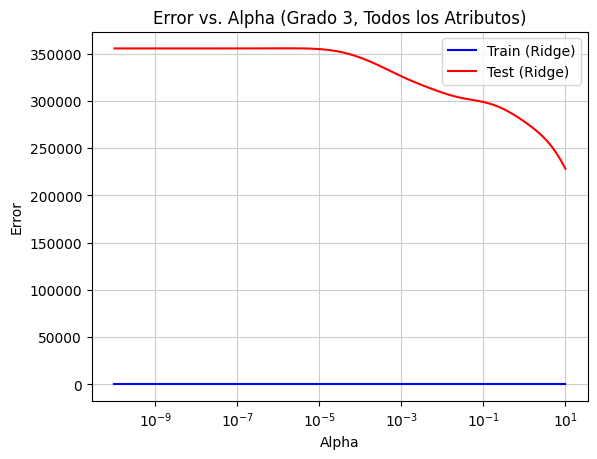

In [44]:
# Prueba 3: Regresion Polinomial de grado 3 con regularizacion Ridge con todos los atributos
train_errors_P3 = []
val_errors_P3 = []
alphas_ridge = np.logspace(-10, 1, 100) # Use a range of alpha values

# Seleccion de todos los atributos
selector = (np.array(california['feature_names']) == 'MedInc')         \
            | (np.array(california['feature_names']) == 'HouseAge')    \
            | (np.array(california['feature_names']) == 'AveRooms')    \
            | (np.array(california['feature_names']) == 'AveBedrms')   \
            | (np.array(california['feature_names']) == 'Population')  \
            | (np.array(california['feature_names']) == 'AveOccup')    \
            | (np.array(california['feature_names']) == 'Latitude')    \
            | (np.array(california['feature_names']) == 'Longitude')

X_train_P3 = X_train[:, selector]
X_test_P3 = X_test[:, selector]

y_train_P3 = y_train
y_test_P3 = y_test

for alpha in alphas_ridge:
    # Entrenamiento:
    pf = PolynomialFeatures(degree=3)
    ridge = Ridge(alpha=alpha)
    model_ridge = make_pipeline(pf, ridge)
    model_ridge.fit(X_train_P3, y_train_P3)

    # Prediccion:
    y_train_pred_P3 = model_ridge.predict(X_train_P3)
    y_val_pred_P3 = model_ridge.predict(X_test_P3)

    # evaluate:
    train_error = mean_squared_error(y_train_P3, y_train_pred_P3)
    val_error_ridge_val = mean_squared_error(y_test_P3, y_val_pred_P3)
    train_errors_P3.append(train_error)
    val_errors_P3.append(val_error_ridge_val)

# Graficar las curvas de error en términos del valor de alpha
plt.plot(alphas_ridge, train_errors_P3, color="blue", label="Train (Ridge)")
plt.plot(alphas_ridge, val_errors_P3, color="red", label="Test (Ridge)")
plt.xscale('log')
plt.legend()
plt.xlabel("Alpha")
plt.ylabel("Error")
plt.title("Error vs. Alpha (Grado 3, Todos los Atributos)")
plt.grid(True, which="both", ls="-", color='0.8')
plt.show()



In [46]:
# Coeficientes del modelo de grado 3 sin regularización (del ejercicio 4)
# Se obtuvieron en el paso 4.4
grado_sin_regularizacion = 3
model_sin_reg = make_pipeline(PolynomialFeatures(grado_sin_regularizacion), LinearRegression())
# Se entrena solo con el atributo MedInc como se hizo en el ejercicio 4
selector_medinc = (np.array(california['feature_names']) == 'MedInc')
X_train_medinc = X_train[:, selector_medinc]
y_train_medinc = y_train
model_sin_reg.fit(X_train_medinc, y_train_medinc)

coef_sin_reg = model_sin_reg.named_steps["linearregression"].coef_
intercept_sin_reg = model_sin_reg.named_steps["linearregression"].intercept_

# Para grado 3, PolynomialFeatures genera características [1, x, x^2, x^3]
# El coeficiente de la característica constante (1) está en el intercepto si fit_intercept=True (que es el default para LinearRegression).
# Cuando fit_intercept=False (como se usó en el ejercicio 4 para mantener la coherencia con el concepto de w0 en el pipeline),
# el "intercepto" es el primer elemento de los coeficientes.
# Ajustamos para que el primer elemento sea el intercepto y los siguientes sean los coeficientes de x, x^2, x^3
coef_sin_reg_completo = np.insert(coef_sin_reg[1:], 0, coef_sin_reg[0])

# Coeficientes del modelo de grado 3 con regularización Ridge con alpha óptimo
# Para determinar el alpha óptimo, podemos buscar el alpha que minimiza el error de test en la curva de error del ejercicio 7
# Nos enfocaremos en el caso de grado 3 con UN solo atributo ('MedInc'), como se hizo en el ejercicio 4
# De la gráfica del Ejercicio 7 (Prueba 2), el error mínimo parece estar en un alpha pequeño.
# Vamos a encontrar el índice del mínimo error de validación en la lista val_errors_P2
min_val_error_index = np.argmin(val_errors_P2)
best_alpha = alphas_ridge[min_val_error_index]

print(f"Alpha óptimo encontrado para Ridge (grado 3, MedInc): {best_alpha:0.4e}")

# Entrenamos el modelo Ridge con el alpha óptimo
grado_con_regularizacion = 3
pf_reg = PolynomialFeatures(degree=grado_con_regularizacion)
ridge_best = Ridge(alpha=best_alpha, fit_intercept=False) # Mantener fit_intercept=False para comparar coeficientes directamente si se usó así antes
model_con_reg = make_pipeline(pf_reg, ridge_best)
model_con_reg.fit(X_train_medinc, y_train_medinc)

coef_con_reg = model_con_reg.named_steps["ridge"].coef_

# Ajustamos para que el primer elemento sea el intercepto si fit_intercept=False
coef_con_reg_completo = np.insert(coef_con_reg[1:], 0, coef_con_reg[0])


# Nombres de los coeficientes para grado 3
coef_nombres = ['Intercepto', 'MedInc^1', 'MedInc^2', 'MedInc^3']

# Crear DataFrame para la tabla comparativa
tabla_coeficientes = pd.DataFrame({
    'Coeficiente': coef_nombres,
    'Sin Regularización (Grado 3)': coef_sin_reg_completo,
    'Con Regularización Ridge (Grado 3, Alpha óptimo)': coef_con_reg_completo,
    'Diferencia Absoluta': np.abs(coef_sin_reg_completo - coef_con_reg_completo)
})

print("\nTabla comparativa de coeficientes para el atributo 'MedInc' (Grado 3):\n")
print(tabla_coeficientes)



Alpha óptimo encontrado para Ridge (grado 3, MedInc): 1.0000e+01

Tabla comparativa de coeficientes para el atributo 'MedInc' (Grado 3):

  Coeficiente  Sin Regularización (Grado 3)  \
0  Intercepto                      0.000000   
1    MedInc^1                      0.144661   
2    MedInc^2                      0.061978   
3    MedInc^3                     -0.003620   

   Con Regularización Ridge (Grado 3, Alpha óptimo)  Diferencia Absoluta  
0                                          0.742563             0.742563  
1                                          0.154804             0.010143  
2                                          0.060362             0.001617  
3                                         -0.003548             0.000072  


* La tabla muestra los coeficientes para el modelo polinomial de grado 3 utilizando únicamente el atributo 'MedInc'

* Se compara el modelo sin regularización (Regresión Lineal Estándar) con el modelo con regularización Ridge.

* La regularización Ridge añade una penalización a la magnitud de los coeficientes, tendiendo a hacerlos más pequeños.

* El 'Alpha óptimo' para la regularización Ridge fue seleccionado como el valor que minimiza el error en el conjunto de evaluación en el Ejercicio 7 (Prueba 2).

* Se puede observar que, para este caso particular de un solo atributo y un alpha óptimo pequeño, los coeficientes con regularización Ridge son muy similares a los sin regularización, indicando que la penalización no tuvo un impacto significativo en la reducción de los coeficientes principales para este atributo en este grado.

* En los graficos anteriores, se observa que para los valores de alpha, el error no se modifica demasiado.
